#Import the Libraries

In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn import linear_model
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

#Convert dataset into a pandas dataframe

In [2]:
data = {
    "num_trucks": [8, 6, 10, 5, 12, 7, 9, 4, 11, 6, 13, 5],
    "avg_route_distance": [215, 188, 252, 159, 318, 194, 247, 136, 281, 176, 339, 153],
    "fuel_cost_per_mile": [3.9, 3.5, 4.1, 3.6, 4.0, 3.8, 3.7, 3.5, 4.3, 3.6, 4.2, 3.4],
    "driver_hours": [98, 74, 126, 61, 139, 91, 104, 59, 137, 69, 149, 72],
    "delivery_volume": [410, 365, 495, 305, 640, 375, 485, 265, 560, 345, 690, 295],
    "late_delivery_rate": [0.09, 0.05, 0.12, 0.06, 0.11, 0.08, 0.10, 0.04, 0.13, 0.07, 0.15, 0.05],
    "warehouse_lighting_score": [7, 8, 6, 9, 5, 7, 6, 8, 5, 9, 4, 8],
    "manager_experience": [11, 6, 8, 4, 14, 7, 12, 3, 10, 5, 15, 2],
    "random_policy_index": [52, 21, 77, 34, 61, 48, 86, 28, 95, 19, 69, 43],
    "logistics_cost": [18350, 15120, 22900, 12650, 27100, 17180, 21350, 11100, 24950, 14500, 29200, 13480]
}

In [3]:
df = pd.DataFrame(data)

In [4]:
df.head()

,num_trucks,avg_route_distance,fuel_cost_per_mile,driver_hours,delivery_volume,late_delivery_rate,warehouse_lighting_score,manager_experience,random_policy_index,logistics_cost
0,8,215,3.9,98,410,0.09,7,11,52,18350
1,6,188,3.5,74,365,0.05,8,6,21,15120
2,10,252,4.1,126,495,0.12,6,8,77,22900
3,5,159,3.6,61,305,0.06,9,4,34,12650
4,12,318,4.0,139,640,0.11,5,14,61,27100


#Conduct Exploratory Data Analysis

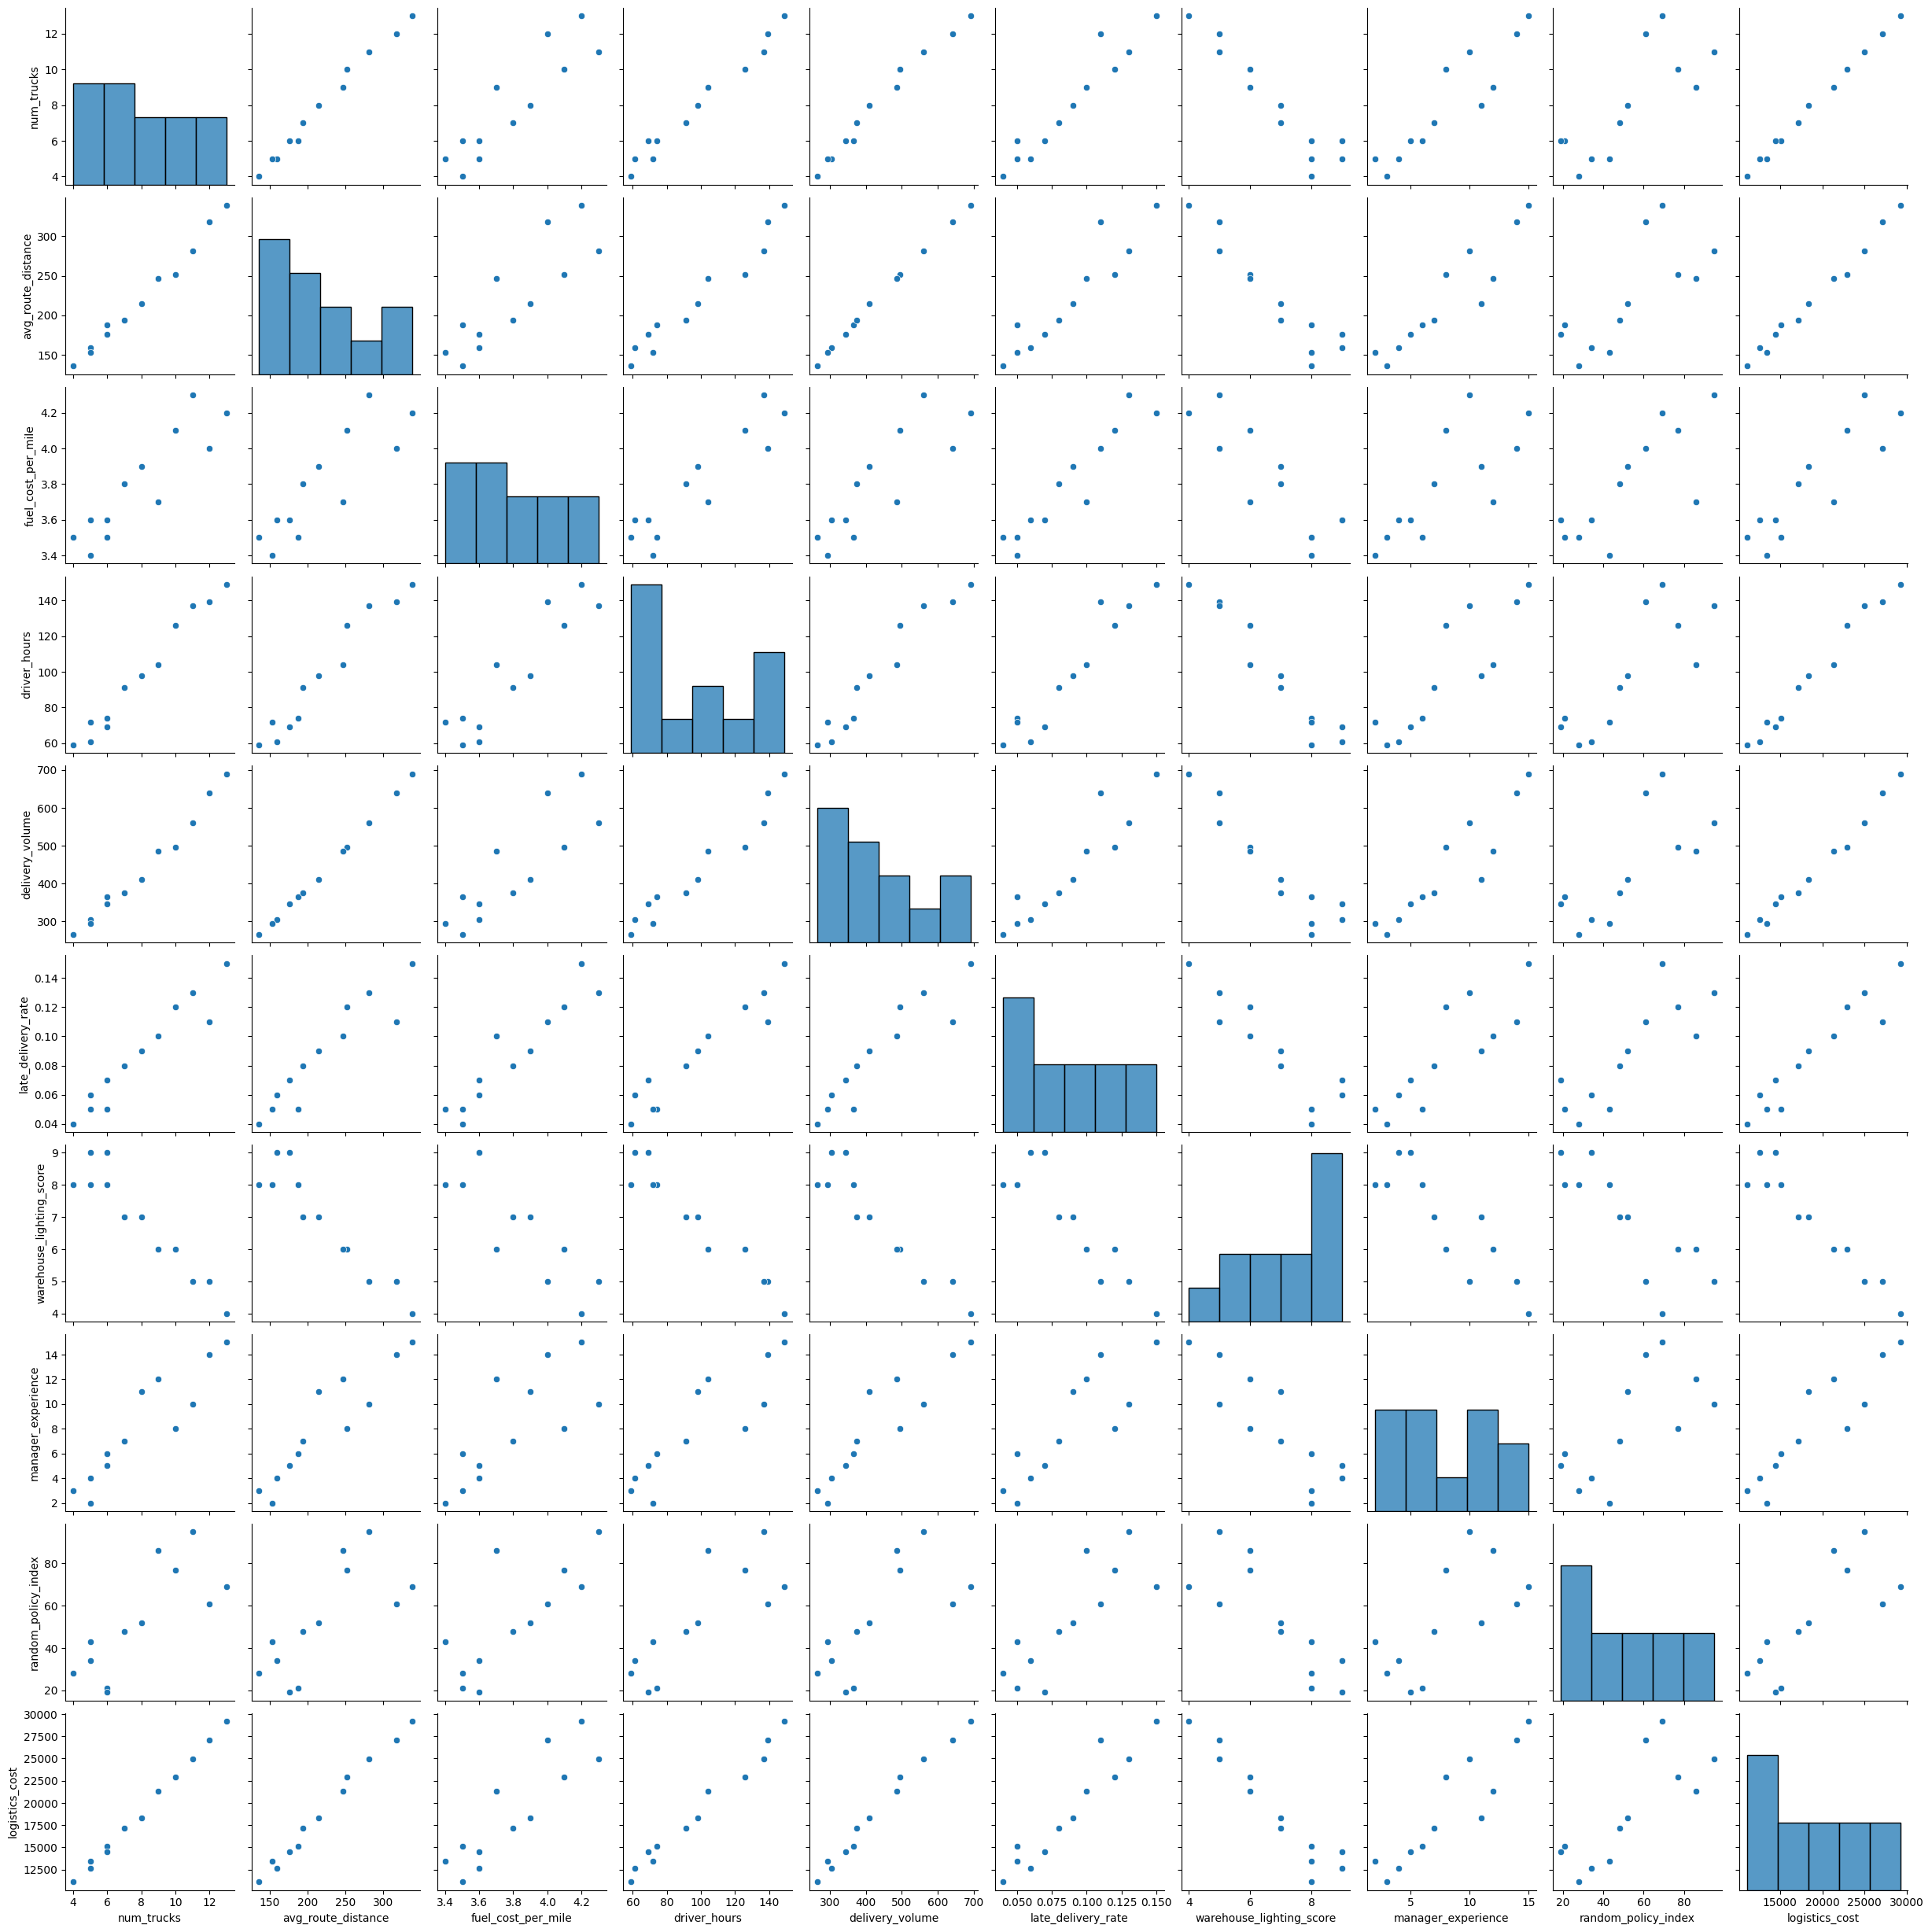

In [5]:
sns.pairplot(df)

#Set the Features and the Target

In [6]:
X = df.drop('logistics_cost', axis = 1)

In [7]:
y = df['logistics_cost']

#Conduct the train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

#Create the Pipeline

In [9]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', linear_model.Lasso(max_iter=10000))
])

#Define the Param_grid

In [10]:
param_grid = {'lasso__alpha': [0.1, 1.0, 1.5, 2.0, 2.5, 3.0]}

#Conduct GridSearchCV

In [11]:
grid = GridSearchCV(pipeline,param_grid,cv=3,refit=True,verbose=2)

#Train and evaluate the model

In [12]:
grid.fit(X_train, y_train)
best_model = grid.best_estimator_
test_preds = best_model.predict(X_test)

Fitting 3 folds for each of 6 candidates, totalling 18 fits
[CV] END ...................................lasso__alpha=0.1; total time=   0.0s
[CV] END ...................................lasso__alpha=0.1; total time=   0.0s
[CV] END ...................................lasso__alpha=0.1; total time=   0.0s
[CV] END ...................................lasso__alpha=1.0; total time=   0.0s
[CV] END ...................................lasso__alpha=1.0; total time=   0.0s
[CV] END ...................................lasso__alpha=1.0; total time=   0.0s
[CV] END ...................................lasso__alpha=1.5; total time=   0.0s
[CV] END ...................................lasso__alpha=1.5; total time=   0.0s
[CV] END ...................................lasso__alpha=1.5; total time=   0.0s
[CV] END ...................................lasso__alpha=2.0; total time=   0.0s
[CV] END ...................................lasso__alpha=2.0; total time=   0.0s
[CV] END ...................................lasso

In [13]:
print("Best Parameters:", grid.best_params_)
print("R2 :", r2_score(y_test, test_preds))

Best Parameters: {'lasso__alpha': 2.5}
Test Accuracy: 0.9952741546795595


In [14]:
best_model.named_steps['lasso'].coef_

array([4185.7090055 ,   11.21900957, -427.08643728, 1309.81224279,
          0.        ,    0.        ,  -87.43911921,  236.43083873,
         71.55763162])

In [15]:
best_model.named_steps['lasso'].intercept_

np.float64(18425.555555555555)

In [16]:
pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_model.named_steps['lasso'].coef_
})

,Feature,Coefficient
0,num_trucks,4185.709006
1,avg_route_distance,11.219010
2,fuel_cost_per_mile,-427.086437
3,driver_hours,1309.812243
4,delivery_volume,0.000000
5,late_delivery_rate,0.000000
6,warehouse_lighting_score,-87.439119
7,manager_experience,236.430839
8,random_policy_index,71.557632
